In [3]:
import numpy as np
import hypernetx as hnx
import hdh
import networkx as nx
import matplotlib.pyplot as plt
import re
import math
import kahypar as kh
import pprint
import subprocess

from pathlib import Path

In [19]:
KAHYPAR_EPSILON = 0.05
GEOMETRIC_COOLING_FACTOR = 0.95

#### ASSUMPTIONS: 
1. Total capacity of the devices is large enough to fit all qubits in the circuit
2. One qubit will never be assigned to multiple devices

#### TODO:

1. Add a param to toggle on/off if every single QPU should have some device assigned
2. Implement zoltan for benchmarking
3. Implement FM for initial state

#### Device Graph Functionality

In [4]:
def build_device_graph(capacities, connectivity):
    device_graph = nx.Graph()
    node_data = [(i, {"capacity": capacities[i], "qubits": []}) for i in range(len(capacities))]
    device_graph.add_nodes_from(node_data)
    device_graph.add_edges_from(connectivity)
    return device_graph

def draw_device_graph(G):
    nx.draw(G, with_labels=True, font_weight='bold')

def two_devices_equal_capacity(qubits):
    cap = (3 * qubits) // 4
    return build_device_graph([cap, cap], [(0, 1)])

#### Initial State

In [5]:
def naive_assignment(hyp, device_graph):
    node_list = list(hyp.nodes.items)
    curr_node = 0
    qubits_assigned = 0

    for node in node_list:
        if qubits_assigned >= device_graph.nodes[curr_node]["capacity"]:
            qubits_assigned = 0
            curr_node += 1
        device_graph.nodes[curr_node]["qubits"].append(node)
        qubits_assigned += 1

def random_assignment(hyp, device_graph):
    node_list = list(hyp.nodes.items)
    available_devices = list(range(len(device_graph.nodes)))

    for node in node_list:
        device = np.random.choice(available_devices)
        device_graph.nodes[device]["qubits"].append(node)

        # check if device is now full
        if len(device_graph.nodes[device]["qubits"]) >= device_graph.nodes[device]["capacity"]:
            available_devices.remove(device)

#### Cost Function

In [6]:
def edge_cost(device_graph, edge):
    for node in device_graph.nodes:
        if edge[0] in device_graph.nodes[node]["qubits"]:
            n1 = node
        if edge[1] in device_graph.nodes[node]["qubits"]:
            n2 = node
    cost = nx.shortest_path_length(device_graph, source=n1, target=n2)
    return cost

def device_graph_cost(device_graph, hyp):
    cost = 0
    for edge_id in hyp.incidence_dict:
        edge = hyp.incidence_dict[edge_id]
        if len(edge) == 2:
            cost += edge_cost(device_graph, edge)
        elif len(edge) == 3: # Toffoli gate
            c1 = edge_cost(device_graph, edge[:2])
            c2 = edge_cost(device_graph, edge[1:])
            c3 = edge_cost(device_graph, [edge[0], edge[2]])
            edge_costs = [c1, c2, c3]
            edge_costs.remove(max(edge_costs))
            cost += edge_costs[0] + edge_costs[1]
    return cost


#### Selecting a Candidate

In [7]:
def get_all_choices(device_graph, empty_slot_weight=False):
    choices = []
    for node in device_graph.nodes:
        choices += [(qubit, node) for qubit in device_graph.nodes[node]["qubits"]]
        free_slots = device_graph.nodes[node]["capacity"] - len(device_graph.nodes[node]["qubits"])

        if empty_slot_weight:
            choices += [(None, node)] * free_slots
        elif free_slots > 0:
            choices.append((None, node))
            
    return choices

def random_choice(device_graph):
    choices = get_all_choices(device_graph)

    # choose two slots to swap, they must be on different devices and at least one must have a qubit
    q1 = choices[np.random.randint(len(choices))]

    choices = [choice for choice in choices if choice[0] != q1[0] and choice[1] != q1[1]]
    q2 = choices[np.random.randint(len(choices))]

    return (q1, q2) 

def swap_qubit_slots(device_graph, slot1, slot2):
    qubit1, node1 = slot1
    qubit2, node2 = slot2

    if qubit1 is not None:
        device_graph.nodes[node1]["qubits"].remove(qubit1)
        device_graph.nodes[node2]["qubits"].append(qubit1)

    if qubit2 is not None:
        device_graph.nodes[node2]["qubits"].remove(qubit2)
        device_graph.nodes[node1]["qubits"].append(qubit2)


#### Acceptance Probability

In [ ]:
# Helpers
def check_swap_cost(device_graph, hyp, slot1, slot2):
    swap_qubit_slots(device_graph, slot1, slot2)
    cost = device_graph_cost(device_graph, hyp)
    swap_qubit_slots(device_graph, (slot1[0], slot2[1]), (slot2[0], slot1[1]))
    return cost

def geometric_cooling(temp):
    return GEOMETRIC_COOLING_FACTOR * temp   

# Probability functions

# Standard Metropolis-Hastings accept function
def accept_probability(device_graph, hyp, slot1, slot2):
    curr_cost = device_graph_cost(device_graph, hyp)
    new_cost = check_swap_cost(device_graph, hyp, slot1, slot2)
    p = min(1.0, curr_cost / new_cost)
    return p

# Simulated Annealing with temperature
def annealing_probability(device_graph, hyp, slot1, slot2, temp):
    curr_cost = device_graph_cost(device_graph, hyp)
    new_cost = check_swap_cost(device_graph, hyp, slot1, slot2)

    exponent = (curr_cost - new_cost) / temp
    p = math.exp(exponent) if exponent < 0 else 1.0
    return p 

#### Full Metropolis Hastings Algorithm

In [9]:
def partition_hypergraph(hyp, device_graph, steps=1000, initial_state="random", annealing=False):
    
    match initial_state:
        case "random":
            random_assignment(hyp, device_graph)
        case "naive":
            naive_assignment(hyp, device_graph)
        case _:
            print("Invalid initial state")
            return None

    temp = 10.0
    for i in range(steps):
        # select a candidate
        slot1, slot2 = random_choice(device_graph)
        
        # calculate acceptance probability
        if annealing:
            temp = geometric_cooling(temp)
            p = annealing_probability(device_graph, hyp, slot1, slot2, temp)    
        else:
            p = accept_probability(device_graph, hyp, slot1, slot2)  

        # accept with probability p
        if np.random.random() < p:
            swap_qubit_slots(device_graph, slot1, slot2)

    return device_graph


#### Input QASM Files --> Hypergraph

In [10]:
IGNORE_TERMS = ['OPENQASM', '//', 'qreg', 'barrier', 'measure']

def clean_argstr(argstr):
    regex = r"[\[\];]"
    argstr = re.sub(regex, "", argstr)
    return argstr.split(',')
    
def qasm_to_hypergraph(qasm_file):
    edges = []
    with open(qasm_file) as f:
        for line in f.readlines():
            terms = line.strip().split()

            # not a gate
            if len(terms) == 0 or terms[0] in IGNORE_TERMS:
                continue
            else:
                args = clean_argstr(terms[1])
                if len(args) >= 2:
                    edges.append(args)

    return hnx.Hypergraph(edges)

def print_hnx(H):
    print(f"{H.incidence_dict}\n".replace("], ", "],\n"))
                        

#### Benchmarking

KaHyPar

In [11]:
def hnx_to_kahypar(hyp, k):
    n_nodes = len(hyp.nodes)
    n_edges = len(hyp.edges)

    nodes = [node for node in hyp.nodes]
    node_map = dict(
        [(nodes[i], i) for i in range(n_nodes)]
    )

    edge_weights   = [1] * n_edges
    vertex_weights = [1] * n_nodes

    # Flatten hyperedges and build the index array.
    edge_indices = []
    edge_vector  = []
    offset = 0
    for he in hyp.incidence_dict:
        edge_vector.extend([node_map[node] for node in hyp.incidence_dict[he]])
        edge_indices.append(offset)
        offset += len(hyp.incidence_dict[he])
    edge_indices.append(offset)

    print(
        n_nodes,
        n_edges,
        edge_indices,
        edge_vector,
        k,
        edge_weights,
        vertex_weights,
    )

    hg = kh.Hypergraph(
        n_nodes,
        n_edges,
        edge_indices,
        edge_vector,
        k,
        edge_weights,
        vertex_weights,
    )
    return hg

def kahypar_partition(hg, k, epsilon):
    ctx = kh.Context()
    ctx.loadINIconfiguration(
        "/home/bamado/Workspace/LFCS/metropolis-hastings-hypergraph-partitioner/dev/lib/python3.13/site-packages/kahypar/config/cut_kKaHyPar_sea20.ini"
    )
    ctx.setK(k)
    ctx.setEpsilon(epsilon)
    ctx.setSeed(42)

    kh.partition(hg, ctx)

    cut = kh.cut(hg)
    assignment = [hg.blockID(v) for v in range(len(list(hg.nodes())))]
    return cut, assignment

def assign_cut_to_device_graph(hyp, device_graph, assignment):
    for i in range(len(assignment)):
        device_graph.nodes[assignment[i]]["qubits"].append(list(hyp.nodes)[i])

Test Orchestration

In [17]:
def test_run(file, **kwargs):
    H = qasm_to_hypergraph(file)
    DG = two_devices_equal_capacity(len(H.nodes))
    partition_hypergraph(H, DG, **kwargs)
    return len(H.edges), device_graph_cost(DG, H)

def test(dir, **kwargs):
    results = []
    control = []
    dirpath = Path(dir)
    for file in dirpath.iterdir():
        if file.is_file():
            print(f"Processing file... {file.name}")

            H = qasm_to_hypergraph(file)

            DG = two_devices_equal_capacity(len(H.nodes))
            partition_hypergraph(H, DG, **kwargs)
            r = len(H.edges), device_graph_cost(DG, H)
            results.append(r)

            hg = hnx_to_kahypar(H, len(H.nodes))
            _, assignment = kahypar_partition(hg, len(DG.nodes), KAHYPAR_EPSILON)
            print(assignment)
            DG = two_devices_equal_capacity(len(H.nodes))
            assign_cut_to_device_graph(H, DG, assignment)
            r = len(H.edges), device_graph_cost(DG, H)
            control.append(r)

            print("Done!")
    return sorted(results, key=lambda x: x[0]), sorted(control, key=lambda x: x[0])

In [13]:
base_results, kahypar_control = test("/home/bamado/Workspace/LFCS/metropolis-hastings-hypergraph-partitioner/test/one_circuit_ghz_indep_tket", annealing=False)

Processing file... monolithic__mqt__ghz_indep_tket__10.qasm
10 9 [0, 2, 4, 6, 8, 10, 12, 14, 16, 18] [0, 1, 1, 2, 2, 3, 3, 4, 4, 5, 5, 6, 6, 7, 7, 8, 8, 9] 10 [1, 1, 1, 1, 1, 1, 1, 1, 1] [1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
+++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++ 
+                    _  __     _   _       ____                               + 
+                   | |/ /__ _| | | |_   _|  _ \ __ _ _ __                    + 
+                   | ' // _` | |_| | | | | |_) / _` | '__|                   + 
+                   | . \ (_| |  _  | |_| |  __/ (_| | |                      + 
+                   |_|\_\__,_|_| |_|\__, |_|   \__,_|_|                      + 
+                                    |___/                                    + 
+                 Karlsruhe Hypergraph Partitioning Framework                 + 
+++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++ 
*****************************************************

In [14]:
annealing_results, _ = test("/home/bamado/Workspace/LFCS/metropolis-hastings-hypergraph-partitioner/test/one_circuit_ghz_indep_tket", annealing=True)

Processing file... monolithic__mqt__ghz_indep_tket__10.qasm
10 9 [0, 2, 4, 6, 8, 10, 12, 14, 16, 18] [0, 1, 1, 2, 2, 3, 3, 4, 4, 5, 5, 6, 6, 7, 7, 8, 8, 9] 10 [1, 1, 1, 1, 1, 1, 1, 1, 1] [1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
[1, 1, 1, 1, 1, 0, 0, 0, 0, 0]
Done!
Processing file... monolithic__mqt__ghz_indep_tket__125.qasm
+++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++ 
+                    _  __     _   _       ____                               + 
+                   | |/ /__ _| | | |_   _|  _ \ __ _ _ __                    + 
+                   | ' // _` | |_| | | | | |_) / _` | '__|                   + 
+                   | . \ (_| |  _  | |_| |  __/ (_| | |                      + 
+                   |_|\_\__,_|_| |_|\__, |_|   \__,_|_|                      + 
+                                    |___/                                    + 
+                 Karlsruhe Hypergraph Partitioning Framework                 + 
++++++++++++++++++++++++++++++++++++

In [15]:
def plot_results(r, l):
    plt.plot([t[0] for t in r], [t[1] for t in r], label=l)
    plt.xlabel("# Multi-Qubit Gates")
    plt.ylabel("Device Graph Cost")
    plt.legend(loc="upper left")
    return plt

<module 'matplotlib.pyplot' from '/home/bamado/Workspace/LFCS/metropolis-hastings-hypergraph-partitioner/dev/lib/python3.13/site-packages/matplotlib/pyplot.py'>

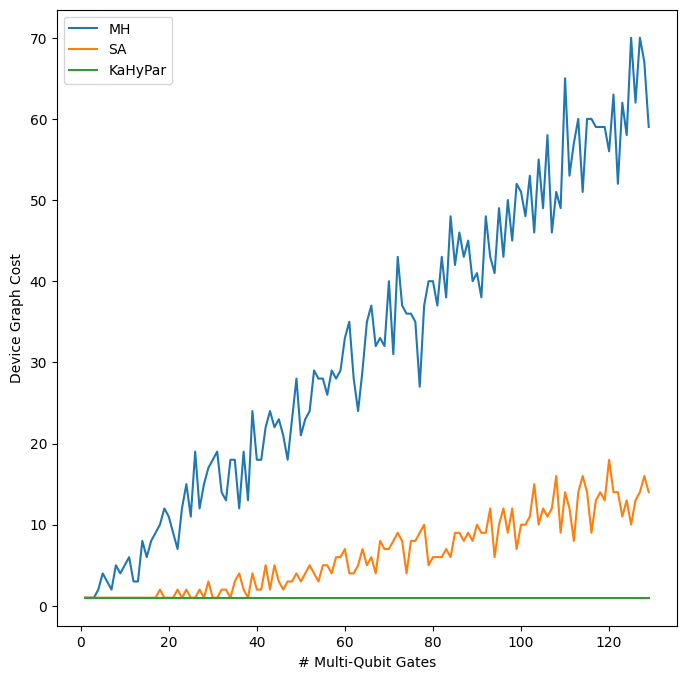

In [16]:
plot_results(base_results, "MH")
plot_results(annealing_results, "SA")
plot_results(kahypar_control, "KaHyPar")

Zoltan (unfinished)

In [1]:
def build_stdin(n_vertices, hyperedges, k):
    lines = [f"{n_vertices} {len(hyperedges)} {k}"]
    for he in hyperedges:
        lines.append(" ".join(map(str, he)))
    return "\n".join(lines)

In [20]:
stdin_data = build_stdin(
    5, 
    [(0, 1), (1, 2, 3), (3, 4)], 
    2
)

result = subprocess.run(
    ["./zoltan_phg_partition"],
    input=stdin_data,
    capture_output=True,
    text=True,
    check=True,
)

cut = int(result.stdout.strip())

FileNotFoundError: [Errno 2] No such file or directory: './zoltan_phg_partition'

In [ ]:
cut